<a href="https://colab.research.google.com/github/emilyteixeira/emilys-cv-journey/blob/main/vis101_t2_aula02_primeiro_contato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

Este é o primeiro contato com código da disciplina. O objetivo é estabelecer a
representação que usaremos o curso inteiro: a imagem como uma matriz de intensidades.
Partimos de carregar e inspecionar uma imagem e chegamos ao primeiro passo de um
sistema de visão, a detecção de bordas.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print('Setup pronto.')

Setup pronto.


## A imagem como matriz

Computacionalmente, uma imagem é um arranjo de números. Cada posição guarda a
intensidade de um pixel. Carregamos uma imagem do disco com o OpenCV e inspecionamos a
sua estrutura, como faríamos ao abrir um conjunto de dados.

In [ ]:
img = cv2.imread("data/apple.jpg")
print("tipo:", type(img))
print("forma (altura, largura, canais):", img.shape)
print("valores:", img.dtype, "de", img.min(), "a", img.max())

tipo: <class 'numpy.ndarray'>
forma (altura, largura, canais): (853, 1280, 3)
valores: uint8 de 0 a 255


A forma é `(altura, largura, 3)`: três **canais** de cor. Os valores são `uint8`,
inteiros de 0 a 255. Um ponto de atenção do OpenCV: a ordem dos canais é **BGR** (azul,
verde, vermelho), e não RGB.

## Visualizar a imagem

O `matplotlib` espera os canais na ordem RGB. Como o OpenCV usa BGR, invertemos a ordem
dos canais com `[:, :, ::-1]` antes de exibir.

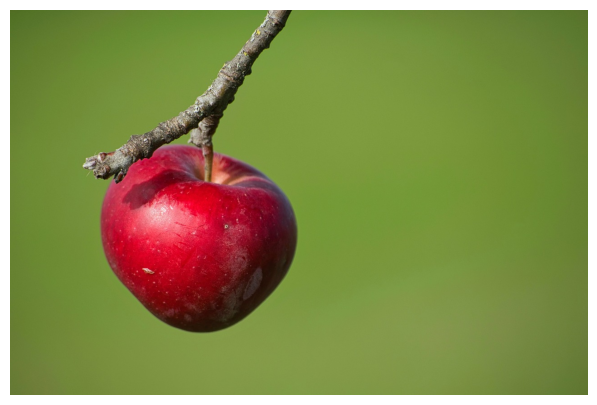

In [ ]:
plt.imshow(img[:, :, ::-1])
plt.axis("off")
plt.show()

## Pixels e região de interesse

Por ser um array, acessar um pixel é indexar a matriz, e recortar uma região de
interesse é fatiar o array, como em qualquer estrutura NumPy.

In [ ]:
pixel = img[400, 600]
print("pixel na linha 400, coluna 600:", pixel, "(ordem B, G, R)")

pixel na linha 400, coluna 600: [116 114 106] (ordem B, G, R)


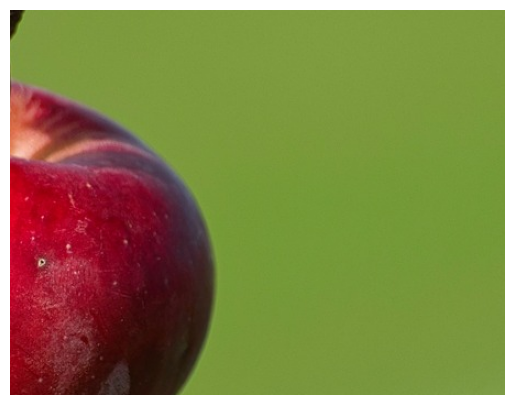

In [ ]:
roi = img[250:600, 450:900]
plt.imshow(roi[:, :, ::-1])
plt.axis("off")
plt.show()

## Os canais de cor

Cada canal é, isoladamente, uma matriz de intensidades. Separando os três, vemos o que
cada um carrega. No canal vermelho, a maçã aparece clara, porque sua intensidade nesse
canal é alta.

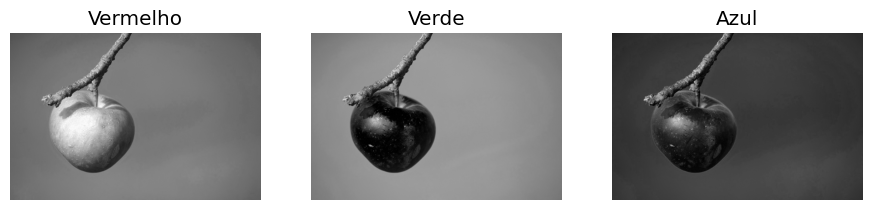

In [ ]:
B, G, R = cv2.split(img)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for a, canal, nome in zip(ax, [R, G, B], ["Vermelho", "Verde", "Azul"]):
    a.imshow(canal, cmap="gray")
    a.set_title(nome)
    a.axis("off")
plt.show()

## Da imagem às bordas

Uma borda é um ponto onde a intensidade muda rapidamente, e medir variação é o papel do
**gradiente**. Trabalhamos com a imagem em tons de cinza, uma única matriz de
intensidades, e aproximamos o gradiente pela diferença entre pixels vizinhos.

In [ ]:
I = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)

I_x = np.zeros_like(I)
I_y = np.zeros_like(I)
I_x[:, 1:] = I[:, 1:] - I[:, :-1]
I_y[1:, :] = I[1:, :] - I[:-1, :]

A magnitude do gradiente, pelo teorema de Pitágoras, mede a força da borda. Um
pixel é declarado borda quando essa força ultrapassa um limiar.

In [ ]:
G = np.sqrt(I_x**2 + I_y**2)
bordas = G > 40
print("força máxima de borda:", round(G.max(), 1))

força máxima de borda: 182.5


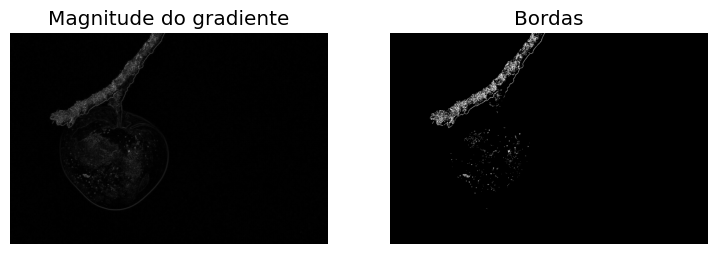

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(G, cmap="gray")
ax[0].set_title("Magnitude do gradiente")
ax[0].axis("off")
ax[1].imshow(bordas, cmap="gray")
ax[1].set_title("Bordas")
ax[1].axis("off")
plt.show()

Saímos da imagem crua e chegamos a um mapa de bordas, o primeiro passo do sistema
de visão estudado na teoria. As bibliotecas trazem um atalho para o mesmo cálculo, com
um filtro mais robusto (Sobel), que será detalhado adiante.

In [ ]:
Sx = cv2.Sobel(I, cv2.CV_64F, 1, 0, ksize=3)
Sy = cv2.Sobel(I, cv2.CV_64F, 0, 1, ksize=3)
G_sobel = np.sqrt(Sx**2 + Sy**2)
print("magnitude máxima. nossa:", round(G.max(), 1), "| Sobel:", round(G_sobel.max(), 1))

magnitude máxima. nossa: 182.5 | Sobel: 859.1


## Síntese

Uma imagem é uma matriz `(altura, largura, canais)` de valores `uint8`. O OpenCV usa a
ordem BGR e o matplotlib espera RGB. Acessar pixels e recortar uma região é indexar e
fatiar o array. Cada canal é uma matriz de intensidades. E o gradiente converte a imagem
em um mapa de bordas, o ponto de partida de um sistema de visão.